# MLB starter strikeout model metrics

Game-log negative binomial (`nb_k_v1`) trained on **2018–2025** starter box scores. **2026 is held out** for a later Hugging Face quote backtest.

The saved artifact was fit on all 2018–2025 starts, so this notebook **refits** on prior seasons and scores the next year. That is the number to trust. Primary score is mean PMF negative log likelihood.

In [2]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.mlb.cli import _load_tables, _prepare_train_frame
from src.mlb.config import load_config
from src.mlb.evaluation.backtest import _ensure_prediction_pmf, _score_predictions
from src.mlb.evaluation.baselines import fit_baselines
from src.mlb.models.serialize import as_strikeout_model, load_model
from src.mlb.models.strikeouts import fit_strikeouts, predict_strikeout_pmf
from src.mlb.schemas import STRIKEOUT_FEATURE_COLUMNS

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

config = load_config(ROOT / "config" / "mlb.yaml")
tables, store = _load_tables(config, fixture=False)
panel = _prepare_train_frame(tables, config)
panel = panel.dropna(subset=["strikeouts", "season", "game_date"]).copy()
panel["season"] = pd.to_numeric(panel["season"], errors="coerce").astype(int)

artifact = store.config.artifact_dir / "strikeouts" / f"{config.model_version}.pkl"
saved_model = as_strikeout_model(load_model(artifact)) if artifact.exists() else None

print(f"Starts in panel: {len(panel):,}")
print(panel.groupby("season").size().rename("starts").to_string())
print(f"Saved model: {artifact if artifact.exists() else 'missing'}")

Starts in panel: 35,712
season
2018    4852
2019    4858
2020    1794
2021    4835
2022    4832
2023    4837
2024    4858
2025    4846
Saved model: /Users/alexgonzalez/Documents/nba_quant/artifacts/mlb/strikeouts/nb_k_v1.pkl


## Expanding-season scores

Each row trains on all earlier seasons and tests that year. Baselines see only the train fold.

In [3]:
def score_split(train: pd.DataFrame, test: pd.DataFrame, label: str) -> list[dict]:
    rng = np.random.default_rng(config.seed)
    y = pd.to_numeric(test["strikeouts"], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(y)
    test_f = test.loc[finite].reset_index(drop=True)
    y = y[finite]
    if len(test_f) == 0:
        return []
    model = fit_strikeouts(train.dropna(subset=["strikeouts"]), config)
    pred = _ensure_prediction_pmf(
        predict_strikeout_pmf(model, test_f, config), test_f, config
    )
    rows = []
    model_scores = _score_predictions(pred, y, config, rng)
    model_scores.update(fold=label, model="strikeout_nb", n_train=int(len(train)))
    rows.append(model_scores)
    for name, frame in fit_baselines(train, test_f, config).items():
        aligned = frame.reset_index(drop=True)
        if len(aligned) != len(test_f):
            continue
        b = _score_predictions(aligned, y, config, rng)
        b.update(fold=label, model=name, n_train=int(len(train)))
        rows.append(b)
    return rows


records: list[dict] = []
for year in range(2021, 2026):
    train = panel.loc[panel["season"] < year]
    test = panel.loc[panel["season"] == year]
    records.extend(score_split(train, test, str(year)))

scores = pd.DataFrame(records)
show = [
    "fold",
    "model",
    "n",
    "n_train",
    "pmf_nll",
    "discrete_crps",
    "mae",
    "rmse",
    "coverage_80",
    "brier_5_5",
    "calibration_slope",
]
metric_table = scores.loc[scores["model"].isin(["strikeout_nb", "league_nb", "marcel", "pitcher_opp"]), show]
metric_table

/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 17 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 17 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/si

,fold,model,n,n_train,pmf_nll,discrete_crps,mae,rmse,coverage_80,brier_5_5,calibration_slope
0,2021,strikeout_nb,"4,835.000",11504,2.255,1.316,1.883,2.358,0.857,0.206,0.949
1,2021,league_nb,"4,835.000",11504,2.354,1.465,2.109,2.610,0.821,0.236,0.208
5,2021,pitcher_opp,"4,835.000",11504,2.283,1.353,1.940,2.415,0.880,0.215,1.232
6,2021,marcel,"4,835.000",11504,2.281,1.348,1.931,2.406,0.883,0.214,1.220
7,2022,strikeout_nb,"4,832.000",16339,2.208,1.258,1.806,2.269,0.878,0.198,1.038
8,2022,league_nb,"4,832.000",16339,2.309,1.398,2.002,2.514,0.840,0.225,0.284
12,2022,pitcher_opp,"4,832.000",16339,2.241,1.296,1.861,2.333,0.898,0.206,1.322
13,2022,marcel,"4,832.000",16339,2.240,1.293,1.860,2.328,0.900,0.205,1.269
14,2023,strikeout_nb,"4,837.000",21171,2.330,1.424,2.034,2.545,0.828,0.232,0.240
15,2023,league_nb,"4,837.000",21171,2.330,1.424,2.034,2.545,0.828,0.232,0.240


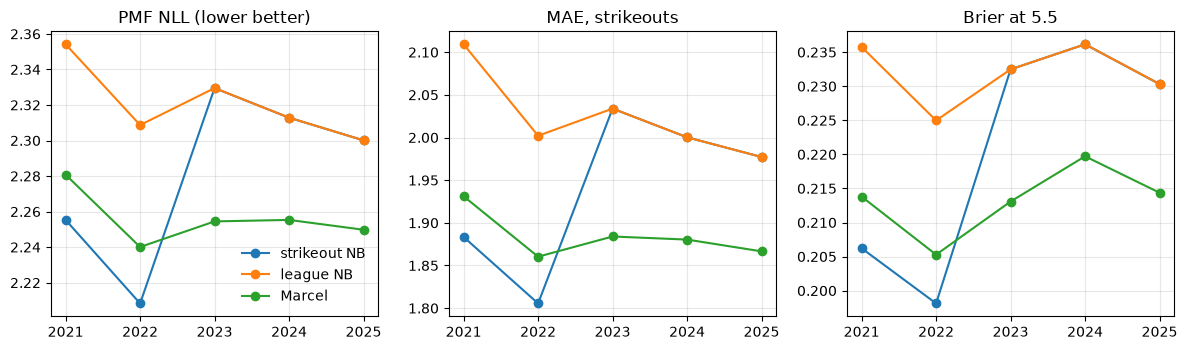

2025 holdout (train 2018-2024)


,fold,model,n,n_train,pmf_nll,discrete_crps,mae,rmse,coverage_80,brier_5_5,calibration_slope
28,2025,strikeout_nb,"4,846.000",30866,2.300,1.382,1.977,2.470,0.846,0.230,0.253
29,2025,league_nb,"4,846.000",30866,2.300,1.382,1.977,2.470,0.846,0.230,0.253
30,2025,rolling_k,"4,846.000",30866,2.282,1.322,1.895,2.380,0.891,0.215,0.795
31,2025,k9_workload,"4,846.000",30866,2.282,1.321,1.895,2.378,0.888,0.214,0.747
32,2025,shrunk_kbf,"4,846.000",30866,2.240,1.288,1.841,2.306,0.896,0.211,1.113
33,2025,pitcher_opp,"4,846.000",30866,2.254,1.311,1.880,2.347,0.891,0.216,1.249
34,2025,marcel,"4,846.000",30866,2.250,1.303,1.867,2.333,0.895,0.214,1.234


In [4]:
nb = scores.loc[scores["model"] == "strikeout_nb"].set_index("fold")
league = scores.loc[scores["model"] == "league_nb"].set_index("fold")
marcel = scores.loc[scores["model"] == "marcel"].set_index("fold")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, col, title in (
    (axes[0], "pmf_nll", "PMF NLL (lower better)"),
    (axes[1], "mae", "MAE, strikeouts"),
    (axes[2], "brier_5_5", "Brier at 5.5"),
):
    ax.plot(nb.index, nb[col], marker="o", label="strikeout NB")
    ax.plot(league.index, league[col], marker="o", label="league NB")
    ax.plot(marcel.index, marcel[col], marker="o", label="Marcel")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

print("2025 holdout (train 2018-2024)")
display(scores.loc[scores["fold"] == "2025", show])

## 2025 holdout detail

Refit on 2018–2024, predict 2025 starts. 80% interval coverage should sit near 0.80 if the PMF is honest.

/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 17 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 17 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/si

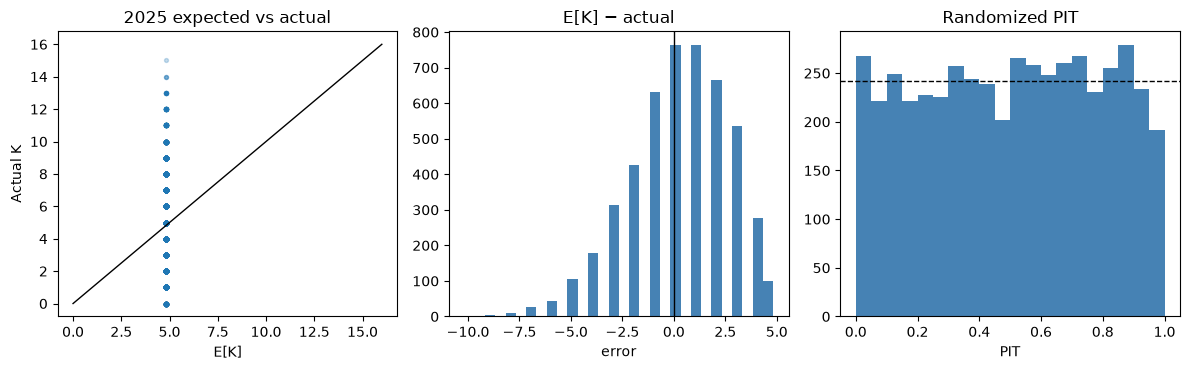

      expected_k  strikeouts  error  pi_lower  pi_upper
mean       4.826       4.783  0.043     2.000     8.000
std        0.000       2.469  2.469     0.000     0.000
50%        4.826       5.000 -0.174     2.000     8.000


In [5]:
train_2025 = panel.loc[panel["season"] < 2025]
test_2025 = panel.loc[panel["season"] == 2025].reset_index(drop=True)
holdout_model = fit_strikeouts(train_2025.dropna(subset=["strikeouts"]), config)
pred_2025 = _ensure_prediction_pmf(
    predict_strikeout_pmf(holdout_model, test_2025, config), test_2025, config
)
y_2025 = pd.to_numeric(test_2025["strikeouts"], errors="coerce").to_numpy(dtype=float)
pred_2025 = pred_2025.copy()
pred_2025["strikeouts"] = y_2025
pred_2025["error"] = pred_2025["expected_k"] - pred_2025["strikeouts"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].scatter(pred_2025["expected_k"], pred_2025["strikeouts"], s=8, alpha=0.25)
lims = [0, 16]
axes[0].plot(lims, lims, color="black", lw=1)
axes[0].set_xlabel("E[K]")
axes[0].set_ylabel("Actual K")
axes[0].set_title("2025 expected vs actual")

axes[1].hist(pred_2025["error"], bins=30, color="steelblue")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("E[K] − actual")
axes[1].set_xlabel("error")

from src.mlb.models.calibration import randomized_pit

from src.mlb.schemas import PMF_COLUMNS

pmf = pred_2025.loc[:, list(PMF_COLUMNS)].to_numpy(dtype=float)
pit = randomized_pit(pmf, y_2025, np.random.default_rng(config.seed))
axes[2].hist(pit, bins=20, range=(0, 1), color="steelblue")
axes[2].axhline(len(pit) / 20, color="black", lw=1, ls="--")
axes[2].set_title("Randomized PIT")
axes[2].set_xlabel("PIT")
fig.tight_layout()
plt.show()

print(
    pred_2025[["expected_k", "strikeouts", "error", "pi_lower", "pi_upper"]]
    .describe()
    .loc[["mean", "std", "50%"]]
)

## Saved artifact coefficients

These are from the **2018–2025 in-sample** fit (`nb_k_v1.pkl`). Plate-discipline and stuff features are missing on this game-log path, so those coefficients sit near zero / median-fill.

In [6]:
if saved_model is None:
    raise FileNotFoundError(artifact)

names = ("intercept",) + tuple(saved_model.feature_names)
coef = pd.Series(np.asarray(saved_model.coef, dtype=float), index=list(names))
print(f"method={saved_model.method}  alpha={saved_model.alpha:.4f}")
display(coef.rename("log_mean_coef").to_frame())

in_sample = _ensure_prediction_pmf(
    predict_strikeout_pmf(saved_model, panel, config), panel, config
)
y_all = pd.to_numeric(panel["strikeouts"], errors="coerce").to_numpy(dtype=float)
in_scores = _score_predictions(
    in_sample, y_all, config, np.random.default_rng(config.seed)
)
print("In-sample 2018-2025 (optimistic; same rows used to fit the artifact)")
display(pd.Series(in_scores).to_frame("in_sample"))

method=glm  alpha=0.0266


,log_mean_coef
intercept,-0.421
expected_bf_oof,0.032
bf_sd_oof,0.013
p_early_exit_oof,-0.302
k_bf_shrunk_365,4.550
k_bf_shrunk_60,1.025
opp_k_rate_vs_hand_shrunk,0.000
lineup_k_rate_shrunk,0.000
csw_750,0.000
whiff_750,0.000


In-sample 2018-2025 (optimistic; same rows used to fit the artifact)


,in_sample
n,"35,712.000"
pmf_nll,2.238
discrete_crps,1.297
mae,1.857
rmse,2.326
coverage_80,0.863
width_80,5.870
pit_mean,0.503
brier_4_5,0.223
brier_5_5,0.207
